In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas     :", pd.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("seaborn    :", sns.__version__)
print()
print("Semua library siap!")

pandas     : 2.2.2
matplotlib : 3.9.0
seaborn    : 0.13.2

Semua library siap!


In [2]:
import pandas as pd

# Load dua file CSV
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items  = pd.read_csv('../data/olist_order_items_dataset.csv')

print("orders loaded:", orders.shape)
print("items loaded :", items.shape)

orders loaded: (99441, 8)
items loaded : (112650, 7)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [6]:
# Cek missing values di orders
print("=== Missing values: orders ===")
print(orders.isnull().sum())

print("\n=== Missing values: items ===")
print(items.isnull().sum())

=== Missing values: orders ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Missing values: items ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [7]:
# Daftar kolom yang perlu dikonversi
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Konversi semua sekaligus
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Verifikasi hasilnya
print(orders[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [8]:
# Ekstrak tahun, bulan, dan nama bulan dari tanggal pembelian
orders['year']       = orders['order_purchase_timestamp'].dt.year
orders['month']      = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%b %Y')
orders['day_of_week']= orders['order_purchase_timestamp'].dt.day_name()

# Lihat hasilnya
orders[['order_purchase_timestamp','year','month','month_name','day_of_week']].head()

,order_purchase_timestamp,year,month,month_name,day_of_week
0,2017-10-02 10:56:33,2017,10,Oct 2017,Monday
1,2018-07-24 20:41:37,2018,7,Jul 2018,Tuesday
2,2018-08-08 08:38:49,2018,8,Aug 2018,Wednesday
3,2017-11-18 19:28:06,2017,11,Nov 2017,Saturday
4,2018-02-13 21:18:39,2018,2,Feb 2018,Tuesday


In [9]:
# Lihat distribusi status order
print(orders['order_status'].value_counts())

# Untuk analisis penjualan, kita hanya perlu order yang sudah delivered
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

print(f"\nTotal order asli  : {len(orders):,}")
print(f"Order delivered   : {len(orders_clean):,}")
print(f"Order dihapus     : {len(orders) - len(orders_clean):,}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total order asli  : 99,441
Order delivered   : 96,478
Order dihapus     : 2,963


In [10]:
# Gabungkan orders dan items berdasarkan order_id
df = orders_clean.merge(items, on='order_id', how='inner')

# Cek hasilnya
print("Shape hasil merge:", df.shape)
print("\nKolom yang tersedia:")
print(df.columns.tolist())

Shape hasil merge: (110197, 18)

Kolom yang tersedia:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year', 'month', 'month_name', 'day_of_week', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [11]:
# Simpan ke folder output
df.to_csv('../output/orders_clean.csv', index=False)
print("Data bersih tersimpan di output/orders_clean.csv")

Data bersih tersimpan di output/orders_clean.csv


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load data bersih
df = pd.read_csv('../output/orders_clean.csv', parse_dates=['order_purchase_timestamp'])

# Ekstrak ulang kolom waktu (karena baru di-load dari CSV)
df['year']        = df['order_purchase_timestamp'].dt.year
df['month']       = df['order_purchase_timestamp'].dt.month
df['month_name']  = df['order_purchase_timestamp'].dt.strftime('%b %Y')
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Style global untuk semua grafik
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Data siap:", df.shape)

Data siap: (110197, 18)


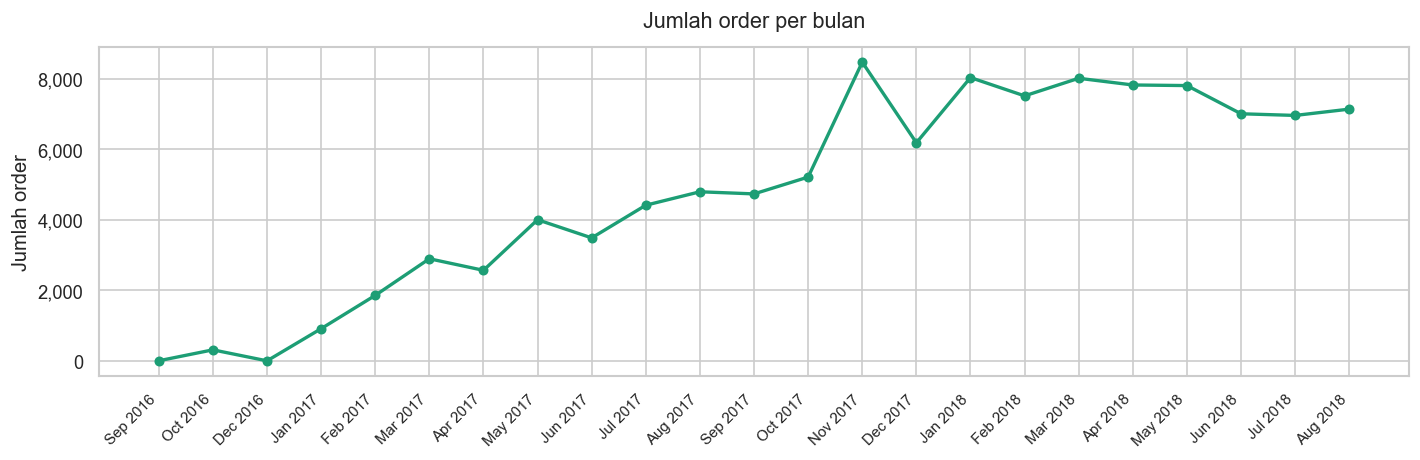

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

# Hitung jumlah order per bulan
monthly = (
    df.groupby(['year', 'month', 'month_name'])
    .size()
    .reset_index(name='total_orders')
    .sort_values(['year', 'month'])
)

ax.plot(
    range(len(monthly)),
    monthly['total_orders'],
    marker='o', linewidth=2,
    color='#1D9E75', markersize=5
)

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_name'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Jumlah order per bulan', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Jumlah order')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../output/01-tren-order-bulanan.png', dpi=150)
plt.show()

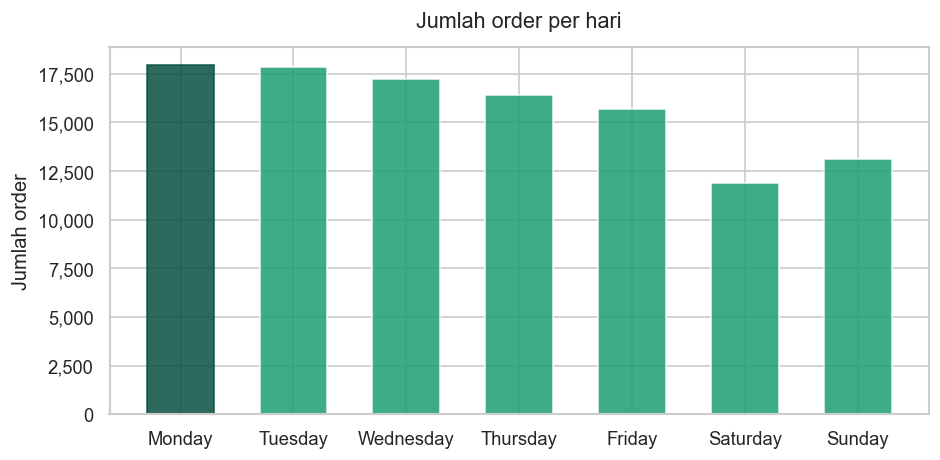

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

# Urutkan hari dari Senin ke Minggu
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

bars = ax.bar(
    day_counts.index,
    day_counts.values,
    color='#1D9E75',
    alpha=0.85,
    width=0.6
)

# Highlight bar tertinggi
max_idx = day_counts.values.argmax()
bars[max_idx].set_color('#085041')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Jumlah order per hari', fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Jumlah order')

plt.tight_layout()
plt.savefig('../output/02-order-per-hari.png', dpi=150)
plt.show()

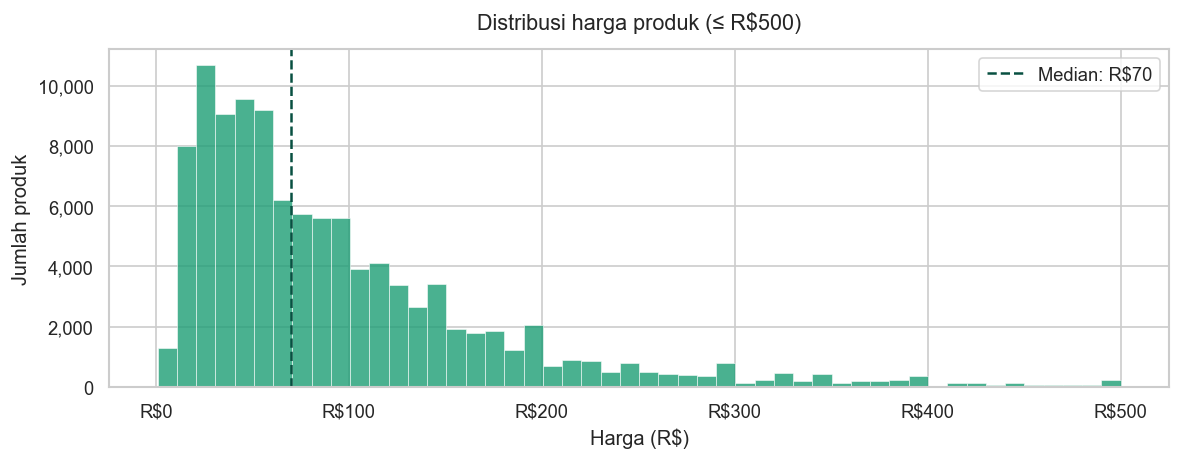

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

# Filter outlier ekstrem supaya grafik lebih mudah dibaca
price_data = df[df['price'] <= 500]['price']

ax.hist(
    price_data,
    bins=50,
    color='#1D9E75',
    alpha=0.8,
    edgecolor='white',
    linewidth=0.4
)

# Tambahkan garis median
median_price = price_data.median()
ax.axvline(median_price, color='#085041', linestyle='--', linewidth=1.5,
           label=f'Median: R${median_price:.0f}')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Distribusi harga produk (≤ R$500)', fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Harga (R$)')
ax.set_ylabel('Jumlah produk')
ax.legend()

plt.tight_layout()
plt.savefig('../output/03-distribusi-harga.png', dpi=150)
plt.show()

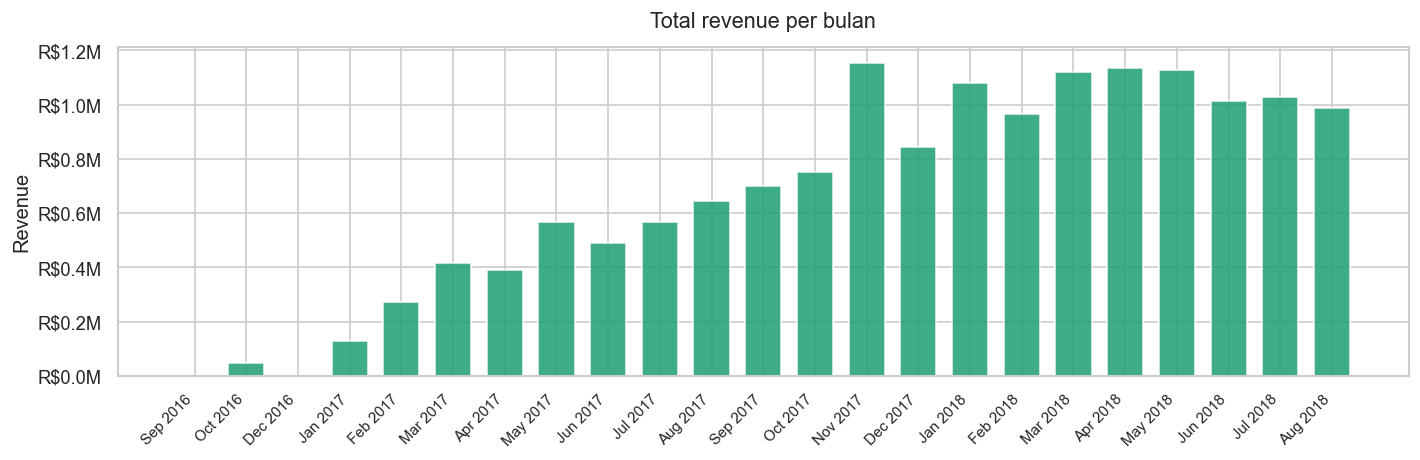

Total revenue keseluruhan : R$15,419,774
Bulan terbaik             : Nov 2017


In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

# Hitung total revenue (harga + ongkir) per bulan
revenue = (
    df.assign(revenue=df['price'] + df['freight_value'])
    .groupby(['year', 'month', 'month_name'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

ax.bar(
    range(len(revenue)),
    revenue['revenue'],
    color='#1D9E75',
    alpha=0.85,
    width=0.7
)

ax.set_xticks(range(len(revenue)))
ax.set_xticklabels(revenue['month_name'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Total revenue per bulan', fontsize=13, fontweight='500', pad=12)
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('../output/04-revenue-bulanan.png', dpi=150)
plt.show()

# Ringkasan angka
total = revenue['revenue'].sum()
best  = revenue.loc[revenue['revenue'].idxmax(), 'month_name']
print(f"Total revenue keseluruhan : R${total:,.0f}")
print(f"Bulan terbaik             : {best}")

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('../output/orders_clean.csv',
                 parse_dates=['order_purchase_timestamp'])

df['year']        = df['order_purchase_timestamp'].dt.year
df['month']       = df['order_purchase_timestamp'].dt.month
df['month_name']  = df['order_purchase_timestamp'].dt.strftime('%b %Y')
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# --- Data untuk tiap grafik ---

# 1. Tren order bulanan
monthly_orders = (
    df.groupby(['year','month','month_name'])
    .size().reset_index(name='total')
    .sort_values(['year','month'])
)

# 2. Order per hari
day_order  = ['Monday','Tuesday','Wednesday',
              'Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

# 3. Distribusi harga (filter outlier)
prices = df[df['price'] <= 500]['price']

# 4. Revenue bulanan
monthly_rev = (
    df.assign(revenue=df['price'] + df['freight_value'])
    .groupby(['year','month','month_name'])['revenue']
    .sum().reset_index()
    .sort_values(['year','month'])
)

C:\Users\asus\AppData\Local\Temp\ipykernel_12812\1829369885.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklabels(


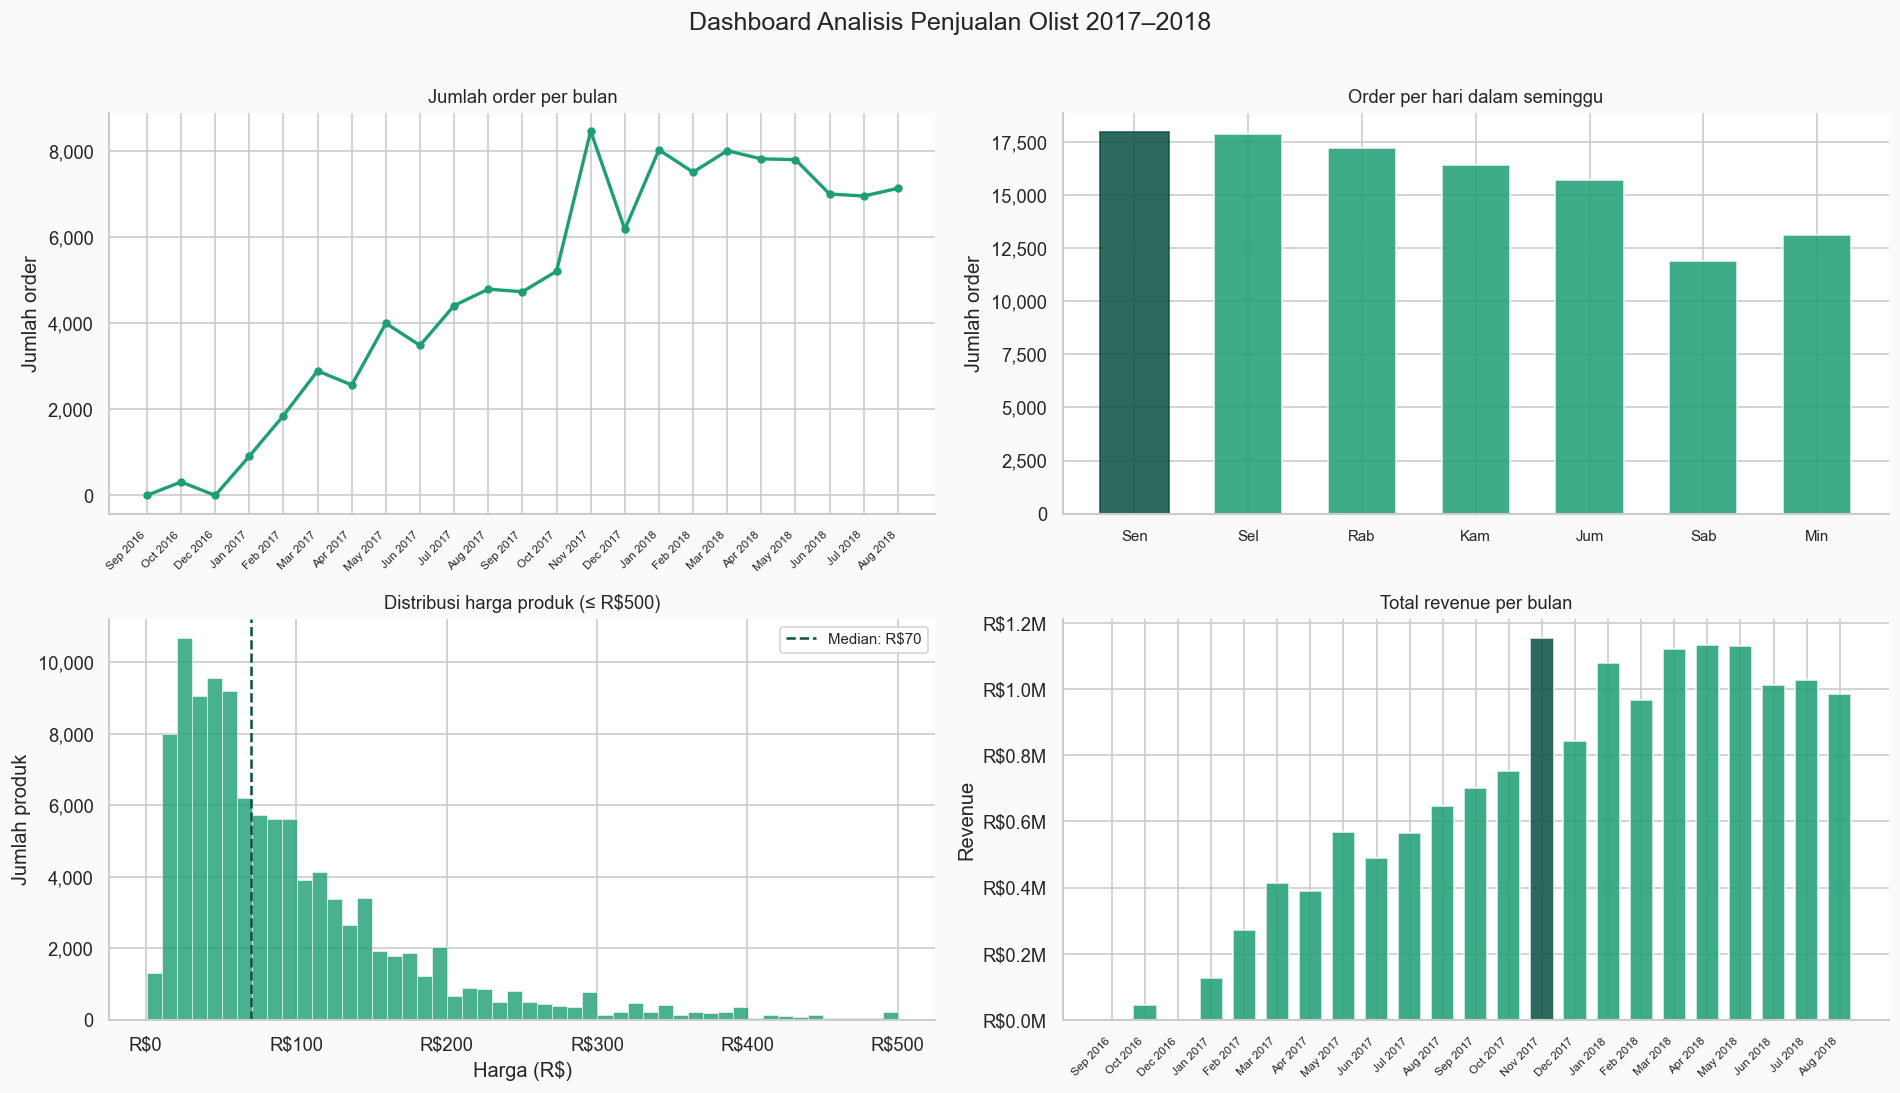

Dashboard tersimpan di output/dashboard.png


In [19]:
sns.set_theme(style='whitegrid', palette='muted')

fig, ax = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Dashboard Analisis Penjualan Olist 2017–2018',
             fontsize=15, fontweight='500', y=1.01)

# ── Grafik 1: tren order bulanan (kiri atas) ──────────────────
x1 = range(len(monthly_orders))
ax[0,0].plot(x1, monthly_orders['total'],
             marker='o', linewidth=2,
             color='#1D9E75', markersize=4)
ax[0,0].set_xticks(x1)
ax[0,0].set_xticklabels(monthly_orders['month_name'],
                         rotation=45, ha='right', fontsize=7)
ax[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax[0,0].set_title('Jumlah order per bulan', fontsize=11, fontweight='500')
ax[0,0].set_ylabel('Jumlah order')

# ── Grafik 2: order per hari (kanan atas) ─────────────────────
bars = ax[0,1].bar(day_counts.index, day_counts.values,
                   color='#1D9E75', alpha=0.85, width=0.6)
bars[day_counts.values.argmax()].set_color('#085041')
ax[0,1].set_xticklabels(
    ['Sen','Sel','Rab','Kam','Jum','Sab','Min'], fontsize=9)
ax[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax[0,1].set_title('Order per hari dalam seminggu',
                  fontsize=11, fontweight='500')
ax[0,1].set_ylabel('Jumlah order')

# ── Grafik 3: distribusi harga (kiri bawah) ───────────────────
ax[1,0].hist(prices, bins=50, color='#1D9E75',
             alpha=0.8, edgecolor='white', linewidth=0.4)
median_p = prices.median()
ax[1,0].axvline(median_p, color='#085041',
                linestyle='--', linewidth=1.5,
                label=f'Median: R${median_p:.0f}')
ax[1,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${int(x):,}'))
ax[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax[1,0].set_title('Distribusi harga produk (≤ R$500)',
                  fontsize=11, fontweight='500')
ax[1,0].set_xlabel('Harga (R$)')
ax[1,0].set_ylabel('Jumlah produk')
ax[1,0].legend(fontsize=9)

# ── Grafik 4: revenue bulanan (kanan bawah) ───────────────────
x4     = range(len(monthly_rev))
max_i4 = monthly_rev['revenue'].values.argmax()
colors = ['#085041' if i == max_i4 else '#1D9E75'
          for i in range(len(monthly_rev))]
ax[1,1].bar(x4, monthly_rev['revenue'],
            color=colors, alpha=0.85, width=0.7)
ax[1,1].set_xticks(x4)
ax[1,1].set_xticklabels(monthly_rev['month_name'],
                         rotation=45, ha='right', fontsize=7)
ax[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
ax[1,1].set_title('Total revenue per bulan',
                  fontsize=11, fontweight='500')
ax[1,1].set_ylabel('Revenue')

fig.patch.set_facecolor('#FAFAF9')

for a in ax.flat:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.subplots_adjust(hspace=0.5, wspace=0.3)

# ── Finishing ─────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('../output/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard tersimpan di output/dashboard.png")